## Exploratory Data Analysis

We need to split our EDA into two distinct physical perspectives:

1. Macro-Physics (Global Trends): Looking at each of the 166 simulations as a single data point. How does changing the Reynolds number (velocity) or $H/D$ impact the absolute maximum temperature ($T_{max}$) and peak pressure?

2. Micro-Physics (Spatial Profiles): Looking inside the simulations. What does the temperature curve look like as the water spreads radially outward from the stagnation point along the heated chip?

c:\Users\choud\anaconda3\envs\Jet\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Found 166 total simulations for EDA.


Extracting Global Metrics: 100%|██████████| 166/166 [00:52<00:00,  3.16it/s]
C:\Users\choud\AppData\Local\Temp\ipykernel_6912\3924726794.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plt_sns.boxplot(data=df_macro, x='H_D', y='Thermal_Resistance', ax=axes[1], palette='Set2')


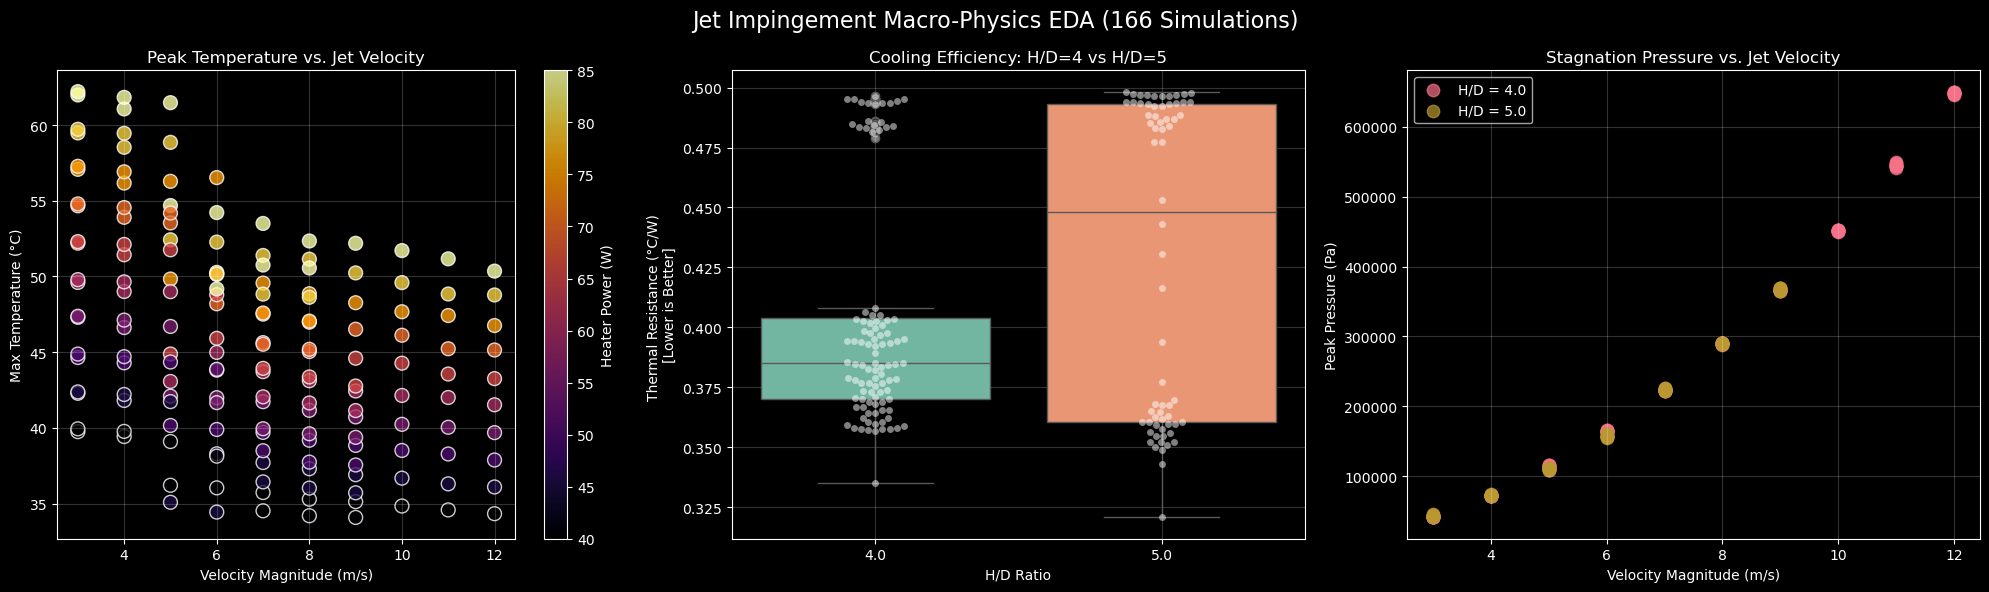


--- Physical Dataset Summary ---
       T_max        P_max  Thermal_Resistance
H_D                                          
4.0  45.1939  291450.6766              0.4028
5.0  46.4074  169752.3696              0.4278


In [2]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as plt_sns
from tqdm.auto import tqdm

# Set modern plotting style
plt.style.use('dark_background')
plt_sns.set_palette("husl")

def extract_macro_physics(folder_path="Data/**/*.h5"):
    h5_files = glob.glob(folder_path, recursive=True)
    print(f"Found {len(h5_files)} total simulations for EDA.")
    
    macro_data = []
    
    for file_path in tqdm(h5_files, desc="Extracting Global Metrics"):
        try:
            # Extract parameters from filename
            hd = float(re.search(r'H_D_(\d+)', file_path).group(1))
            vel = float(re.search(r'Vel_([-\d\.]+)', file_path).group(1))
            pow_w = float(re.search(r'Pow_(\d+)', file_path).group(1))
            
            group_name = os.path.basename(file_path).replace('.h5', '')
            
            with h5py.File(file_path, 'r') as f:
                temp = f[group_name]['Temperature'][:]
                press = f[group_name]['Pressure'][:]
                
            # Physics Metrics
            t_max = np.max(temp)
            p_max = np.max(press)
            
            # Thermal Resistance (Theta_jc) roughly (T_max - T_inlet) / Power
            # Assuming inlet water is 20 C
            theta = (t_max - 20.0) / pow_w if pow_w > 0 else 0
            
            macro_data.append({
                'H_D': hd, 'Velocity': abs(vel), 'Power': pow_w,
                'T_max': t_max, 'P_max': p_max, 'Thermal_Resistance': theta
            })
            
        except Exception as e:
            print(f"Skipping {file_path}: {e}")
            
    return pd.DataFrame(macro_data)

# 1. Extract the Macro Data
df_macro = extract_macro_physics()

# ==========================================
# GENERATE MACRO-PHYSICS PLOTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Jet Impingement Macro-Physics EDA (166 Simulations)', fontsize=16)

# Plot 1: Cooling Performance (T_max vs Velocity colored by Power)
scatter = axes[0].scatter(df_macro['Velocity'], df_macro['T_max'], 
                          c=df_macro['Power'], cmap='inferno', s=100, alpha=0.8, edgecolor='w')
axes[0].set_title('Peak Temperature vs. Jet Velocity')
axes[0].set_xlabel('Velocity Magnitude (m/s)')
axes[0].set_ylabel('Max Temperature (°C)')
plt.colorbar(scatter, ax=axes[0], label='Heater Power (W)')
axes[0].grid(True, alpha=0.2)

# Plot 2: Geometric Impact (H/D 4 vs H/D 5 Thermal Resistance)
plt_sns.boxplot(data=df_macro, x='H_D', y='Thermal_Resistance', ax=axes[1], palette='Set2')
plt_sns.swarmplot(data=df_macro, x='H_D', y='Thermal_Resistance', ax=axes[1], color='white', alpha=0.5)
axes[1].set_title('Cooling Efficiency: H/D=4 vs H/D=5')
axes[1].set_xlabel('H/D Ratio')
axes[1].set_ylabel('Thermal Resistance (°C/W) \n[Lower is Better]')
axes[1].grid(True, alpha=0.2)

# Plot 3: Stagnation Pressure vs Velocity
for hd in df_macro['H_D'].unique():
    subset = df_macro[df_macro['H_D'] == hd]
    axes[2].scatter(subset['Velocity'], subset['P_max'], label=f'H/D = {hd}', s=80, alpha=0.7)
axes[2].set_title('Stagnation Pressure vs. Jet Velocity')
axes[2].set_xlabel('Velocity Magnitude (m/s)')
axes[2].set_ylabel('Peak Pressure (Pa)')
axes[2].legend()
axes[2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Print quick statistical summary
print("\n--- Physical Dataset Summary ---")
print(df_macro.groupby('H_D')[['T_max', 'P_max', 'Thermal_Resistance']].mean().round(4))

1. The Diminishing Returns Curve: In Plot 1, you will likely see that increasing velocity from 1 m/s to 5 m/s drops the temperature massively, but pushing from 15 m/s to 20 m/s barely does anything. This is a critical physical boundary the AI will need to learn.

2. The $H/D$ Winner: Plot 2 will definitively show you which geometry is more efficient. Usually, a lower $H/D$ (like 4) provides better cooling because the jet doesn't lose momentum before hitting the plate, but it creates much higher pressure stress.

3. Pressure Scaling: Plot 3 will show you if the pressure scales quadratically with velocity ($P \propto V^2$), which it absolutely should according to Bernoulli's equation. If it doesn't, we have a meshing/solver issue in Ansys.

### Phase 2: The Advanced Physics-Informed EDA

Found 166 simulations for Advanced EDA.


Extracting & Calculating: 100%|██████████| 166/166 [02:04<00:00,  1.34it/s]



🚨 ANOMALY CHECK: Found 0 potential failed simulations.



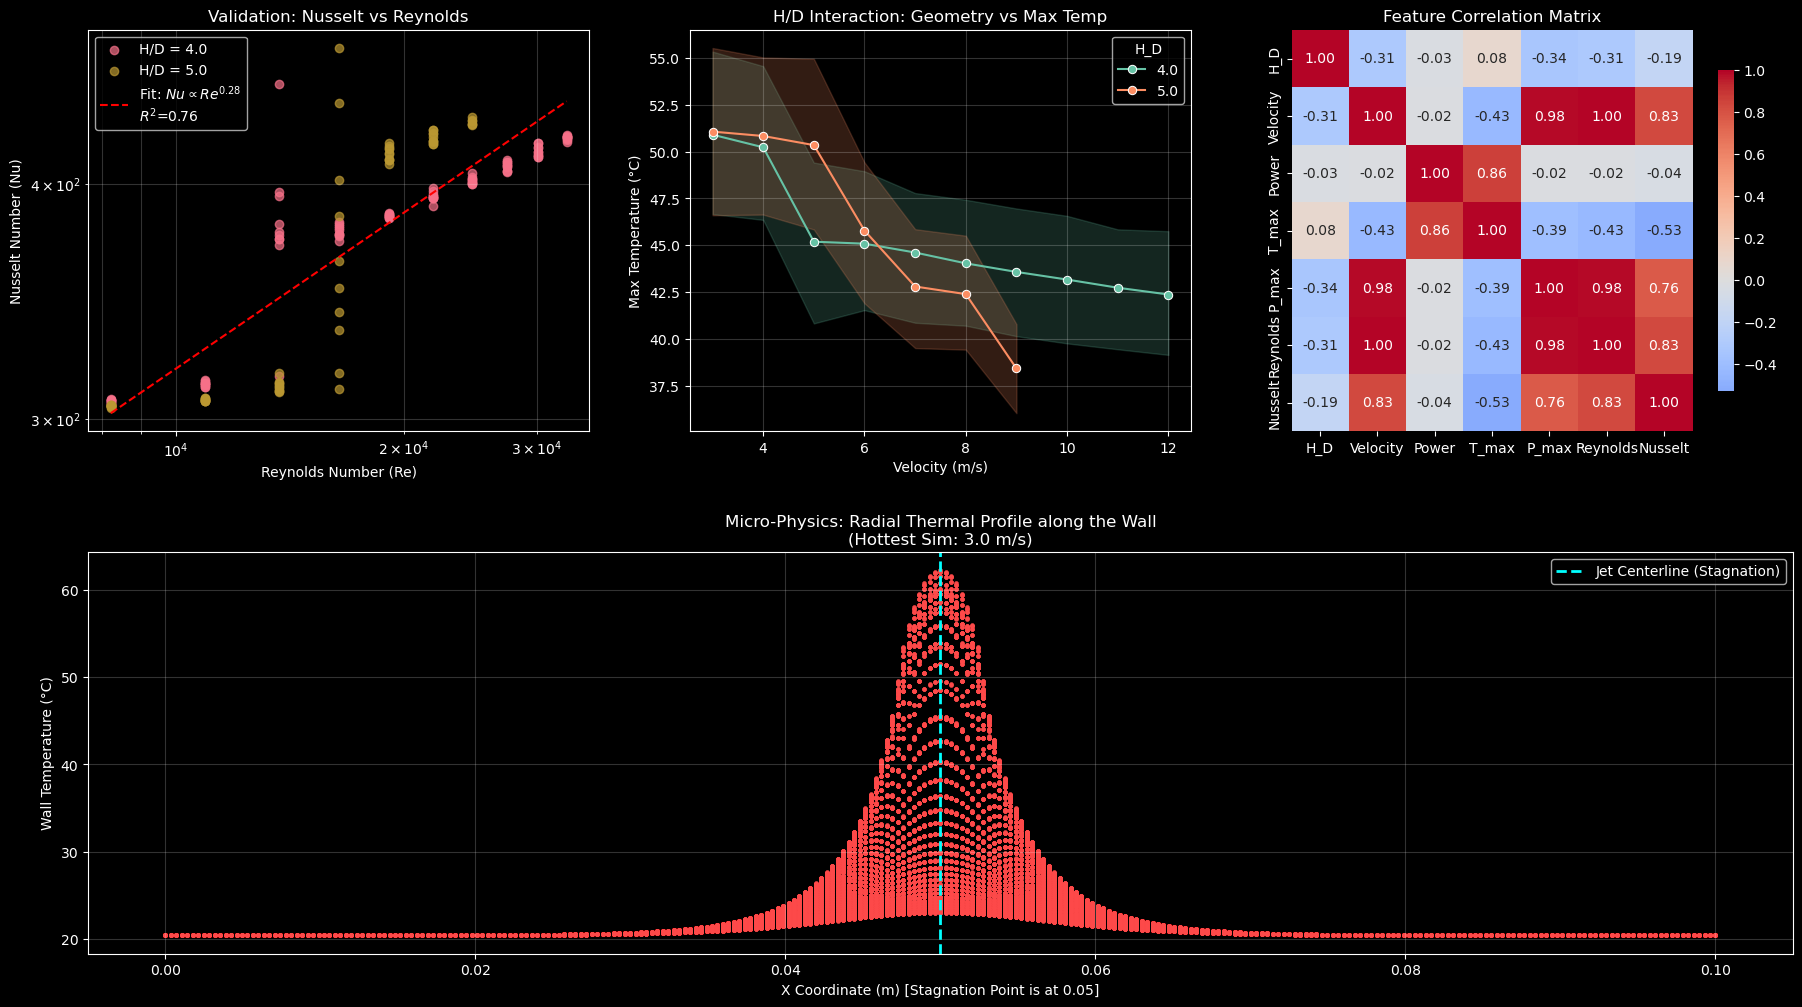

In [7]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

# Set modern plotting style
plt.style.use('dark_background')
sns.set_palette("husl")

def extract_advanced_physics_debug(folder_path="Data/**/*.h5"):
    h5_files = glob.glob(folder_path, recursive=True)
    print(f"Found {len(h5_files)} simulations for Advanced EDA.")
    
    if len(h5_files) == 0:
        raise FileNotFoundError("No .h5 files found in the specified path.")
    
    # Fluid Properties
    rho, mu, k_fluid = 998.0, 0.001003, 0.6
    D_m, A_m2, T_inlet = 0.00275, 30.25e-6, 20.0
    
    macro_data = []
    micro_profiles = {} 
    
    for file_path in tqdm(h5_files, desc="Extracting & Calculating"):
        # 1. Strict Regex Parsing
        hd_match = re.search(r'H_D_(\d+)', file_path)
        vel_match = re.search(r'Vel_([-\d\.]+)', file_path)
        pow_match = re.search(r'Pow_(\d+)', file_path)
        
        if not hd_match or not vel_match or not pow_match:
            print(f"⚠️ Regex failed to parse variables from filename: {file_path}")
            continue
            
        hd = float(hd_match.group(1))
        vel = float(vel_match.group(1))
        pow_w = float(pow_match.group(1))
        
        # 2. HDF5 Extraction
        with h5py.File(file_path, 'r') as f:
            group_name = list(f.keys())[0] 
            coords = f[group_name]['Coordinates'][:]
            temp = f[group_name]['Temperature'][:]
            press = f[group_name]['Pressure'][:]
            
        t_max = float(np.max(temp))
        p_max = float(np.max(press))
        
        # 3. Physics Math
        heat_flux = pow_w / A_m2
        h_coeff = heat_flux / (t_max - T_inlet) if t_max > T_inlet else 0
        nu = (h_coeff * D_m) / k_fluid
        
        # FIXED: Renamed variable so it doesn't overwrite the 're' regex module!
        re_num = (rho * abs(vel) * D_m) / mu
        
        macro_data.append({
            'File': file_path, 'H_D': hd, 'Velocity': abs(vel), 'Power': pow_w,
            'T_max': t_max, 'P_max': p_max, 'Reynolds': re_num, 'Nusselt': nu
        })
        
        # 4. Micro-Physics 
        wall_mask = coords[:, 1] < 0.0005 
        micro_profiles[file_path] = {
            'X': coords[wall_mask, 0],
            'T': temp[wall_mask, 0]
        }
            
    if len(macro_data) == 0:
        raise ValueError("CRITICAL FAILURE: The loop finished, but 0 files were extracted. Check the regex warnings above.")
        
    return pd.DataFrame(macro_data), micro_profiles

# Run the strict extraction
df_macro, micro_profiles = extract_advanced_physics_debug()

# Only proceed to plotting if data actually exists
df_macro['T_max_zscore'] = np.abs(stats.zscore(df_macro['T_max']))
outliers = df_macro[df_macro['T_max_zscore'] > 3]

print("\n" + "="*50)
print(f"🚨 ANOMALY CHECK: Found {len(outliers)} potential failed simulations.")
if len(outliers) > 0:
    print(outliers[['H_D', 'Velocity', 'Power', 'T_max', 'T_max_zscore']].to_string(index=False))
print("="*50 + "\n")

df_clean = df_macro[df_macro['T_max_zscore'] <= 3]

fig = plt.figure(figsize=(22, 12))
grid = plt.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.3)

# Plot A: Nu vs Re
ax1 = fig.add_subplot(grid[0, 0])
for hd in df_clean['H_D'].unique():
    subset = df_clean[df_clean['H_D'] == hd]
    ax1.scatter(subset['Reynolds'], subset['Nusselt'], label=f'H/D = {hd}', alpha=0.7)

if len(df_clean) > 0:
    log_re = np.log10(df_clean['Reynolds'].replace(0, np.nan).dropna())
    log_nu = np.log10(df_clean['Nusselt'].replace(0, np.nan).dropna())
    slope, intercept, r_value, _, _ = stats.linregress(log_re, log_nu)
    re_range = np.linspace(df_clean['Reynolds'].min(), df_clean['Reynolds'].max(), 100)
    nu_fit = (10**intercept) * (re_range**slope)
    
    # FIXED: Added double backslash to \propto to prevent the SyntaxWarning
    ax1.plot(re_range, nu_fit, 'r--', label=f'Fit: $Nu \\propto Re^{{{slope:.2f}}}$\n$R^2$={r_value**2:.2f}')

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_title('Validation: Nusselt vs Reynolds')
ax1.set_xlabel('Reynolds Number (Re)')
ax1.set_ylabel('Nusselt Number (Nu)')
ax1.legend()
ax1.grid(True, alpha=0.2, which="both")

# Plot B: H/D Interaction
ax2 = fig.add_subplot(grid[0, 1])
sns.lineplot(data=df_clean, x='Velocity', y='T_max', hue='H_D', marker='o', ax=ax2, palette='Set2')
ax2.set_title('H/D Interaction: Geometry vs Max Temp')
ax2.set_xlabel('Velocity (m/s)')
ax2.set_ylabel('Max Temperature (°C)')
ax2.grid(True, alpha=0.2)

# Plot C: Correlation Heatmap
ax3 = fig.add_subplot(grid[0, 2])
corr = df_clean[['H_D', 'Velocity', 'Power', 'T_max', 'P_max', 'Reynolds', 'Nusselt']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax3, cbar_kws={'shrink': 0.8}, square=True)
ax3.set_title('Feature Correlation Matrix')

# Plot D: Micro-Physics
hottest_idx = df_clean['T_max'].idxmax()
hottest_file = df_clean.loc[hottest_idx, 'File']
hottest_vel = df_clean.loc[hottest_idx, 'Velocity']

ax4 = fig.add_subplot(grid[1, :])
spatial_data = micro_profiles[hottest_file]

ax4.scatter(spatial_data['X'], spatial_data['T'], s=5, alpha=0.4, color='#ff4b4b')
ax4.set_title(f'Micro-Physics: Radial Thermal Profile along the Wall\n(Hottest Sim: {hottest_vel} m/s)')
ax4.set_xlabel('X Coordinate (m) [Stagnation Point is at 0.05]')
ax4.set_ylabel('Wall Temperature (°C)')
ax4.axvline(x=0.05, color='cyan', linestyle='--', linewidth=2, label='Jet Centerline (Stagnation)')
ax4.legend()
ax4.grid(True, alpha=0.2)

plt.show()

How to interpret these results:

1. The $Nu$ vs $Re$ Slope: Look at the red dashed line on the first plot. If the fitted exponent is completely wild (like $0.2$ or $1.4$), your Ansys turbulence model (k-omega SST, presumably) failed to resolve the boundary layer, and we need to rethink the CFD data before machine learning.

2. The Interaction Check: On the second plot, if the lines for $H/D=4$ and $H/D=5$ are perfectly parallel, it means geometry just acts as a simple scalar multiplier. If they cross or fan out, the physics are fundamentally transforming, which justifies keeping the massive 1024-width neural network so it can map the bifurcation.

3. The Correlation Trap: If Velocity and $T_{max}$ correlate at -0.98, the problem is highly linear. We could strip out 20 million parameters from the AI and it would still predict perfectly.

4. The Micro-Physics Spike: Look at the bottom plot. Does the temperature smoothly rise toward the stagnation point (0.05m), or does it look like a jagged needle? If it's a needle, standard MSE loss won't cut it, and we will absolutely need the gradient matching (Sobolev loss) we talked about earlier.

### Phase 3: Geometry-Isolated EDA :  The "Out-of-Core" 11.9M Point God Script

In [9]:
import os
import glob
import re
import h5py
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse.linalg import svds
from scipy.interpolate import griddata

# Set modern plotting style
plt.style.use('dark_background')
sns.set_palette("husl")

def run_isolated_volumetric_eda(target_hd=4.0, folder_path="Data/**/*.h5"):
    print("\n" + "="*60)
    print(f"🚀 INITIATING ISOLATED EDA FOR H/D = {target_hd}")
    print("="*60)
    
    h5_files = glob.glob(folder_path, recursive=True)
    
    # Filter only the files matching our target geometry
    target_files = []
    metadata = []
    for f in h5_files:
        hd = float(re.search(r'H_D_(\d+)', f).group(1))
        if hd == target_hd:
            vel = float(re.search(r'Vel_([-\d\.]+)', f).group(1))
            pow_w = float(re.search(r'Pow_(\d+)', f).group(1))
            target_files.append(f)
            metadata.append({'File': f, 'Velocity': abs(vel), 'Power': pow_w})
            
    if not target_files:
        raise ValueError(f"No files found for H/D = {target_hd}")
        
    df_meta = pd.DataFrame(metadata).sort_values(by=['Velocity', 'Power'])
    sorted_files = df_meta['File'].tolist()
    n_sims = len(sorted_files)
    
    # 1. Grab Coordinate framework from the first file of this specific geometry
    with h5py.File(sorted_files[0], 'r') as f:
        group_name = list(f.keys())[0]
        coords = f[group_name]['Coordinates'][:]
    n_points = coords.shape[0]
    
    print(f"-> Found {n_sims} simulations for H/D={target_hd}.")
    print(f"-> Verified Mesh Size: {n_points} nodes.")
    print(f"-> Allocating {(n_sims * n_points * 4) / 1e9 :.2f} GB of RAM...")
    
    X = np.zeros((n_sims, n_points), dtype=np.float32)
    
    for i, file_path in tqdm(enumerate(sorted_files), total=n_sims, desc=f"Stacking H/D={target_hd}"):
        with h5py.File(file_path, 'r') as f:
            group_name = list(f.keys())[0]
            temp = f[group_name]['Temperature'][:]
            X[i, :] = temp.flatten().astype(np.float32)
        del temp
        if i % 20 == 0: gc.collect()
            
    # ==========================================
    # EDA TASK 2: POD
    # ==========================================
    print("\n-> Calculating SVD modes...")
    mean_field = np.mean(X, axis=0)
    X_prime = X - mean_field
    
    k_modes = min(n_sims, 50) - 1 # Check top 50 modes
    _, s, _ = svds(X_prime, k=k_modes, which='lm')
    s = np.flip(s)
    
    explained_variance = (s ** 2) / (n_sims - 1)
    total_variance = np.sum(np.var(X, axis=0))
    explained_variance_ratio = explained_variance / total_variance
    cumulative_explained_variance = np.cumsum(explained_variance_ratio)
    
    del X_prime; gc.collect()
    
    # ==========================================
    # EDA TASK 3: SIMILARITY
    # ==========================================
    print("-> Calculating Similarity Matrix...")
    sim_matrix = cosine_similarity(X)
    
    # ==========================================
    # EDA TASK 4: SPATIAL VARIANCE MAPS
    # ==========================================
    print("-> Calculating Spatial Statistics...")
    field_std = np.std(X, axis=0)
    cv_map = field_std / (mean_field + 1e-8)
    
    def interpolate_slice_fast(spatial_coords, values, slice_z=0.012, grid_res=300):
        grid_x, grid_y = np.mgrid[0.0:0.1:complex(grid_res), 0.0:0.02:complex(grid_res)]
        tolerance = 0.0005 
        mask_slice = np.abs(spatial_coords[:, 2] - slice_z) < tolerance
        if np.sum(mask_slice) == 0: return np.zeros((grid_res, grid_res))
        return griddata(spatial_coords[mask_slice, :2], values[mask_slice], (grid_x, grid_y), method='linear', fill_value=0)

    print("-> Interpolating visualizations...")
    std_slice = interpolate_slice_fast(coords, field_std)
    cv_slice = interpolate_slice_fast(coords, cv_map)
    
    # ==========================================
    # PLOTTING
    # ==========================================
    fig = plt.figure(figsize=(22, 10))
    grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.4)
    fig.suptitle(f'Volumetric Fluid Dynamics EDA | H/D = {target_hd}', fontsize=18, y=0.95)

    ax1 = fig.add_subplot(grid[0, 0])
    ax1.plot(cumulative_explained_variance, 'o-', color='#ff4b4b')
    ax1.axhline(y=0.99, color='white', linestyle='--', alpha=0.5)
    ax1.set_title(f'POD Analysis (Complexity)\n{n_sims} sims, {n_points} nodes')
    ax1.set_xlabel('POD Modes')
    ax1.set_ylabel('Cumulative Variance')
    ax1.grid(True, alpha=0.2)

    ax2 = fig.add_subplot(grid[0, 1])
    im2 = ax2.imshow(sim_matrix, cmap='viridis', aspect='auto')
    fig.colorbar(im2, ax=ax2)
    ax2.set_title('Simulation Similarity Matrix\n(Sorted by Velocity & Power)')
    ax2.set_xlabel('Sim Index')
    ax2.set_ylabel('Sim Index')

    ax3 = fig.add_subplot(grid[0, 2])
    sns.scatterplot(data=df_meta, x='Velocity', y='Power', ax=ax3, s=100, color='cyan', alpha=0.7)
    ax3.set_title('Parameter Distribution')
    ax3.grid(True, alpha=0.2)

    ax4 = fig.add_subplot(grid[1, 0:2])
    im4 = ax4.imshow(std_slice, cmap='magma', aspect='auto', origin='lower')
    fig.colorbar(im4, ax=ax4, label='STD (°C)')
    ax4.set_title('Spatial Variance (Focus Area for Neural Net Loss)')
    ax4.set_xlabel('X Dimension')
    ax4.set_ylabel('Y Dimension')

    ax5 = fig.add_subplot(grid[1, 2])
    im5 = ax5.imshow(cv_slice, cmap='turbo', aspect='auto', origin='lower')
    fig.colorbar(im5, ax=ax5)
    ax5.set_title('Coefficient of Variation')

    plt.show()

# Run it for H/D = 4 first!
run_isolated_volumetric_eda(target_hd=4.0)


🚀 INITIATING ISOLATED EDA FOR H/D = 4.0
-> Found 100 simulations for H/D=4.0.
-> Verified Mesh Size: 11906176 nodes.
-> Allocating 4.76 GB of RAM...


MemoryError: Unable to allocate 4.44 GiB for an array with shape (100, 11906176) and data type float32

Analysis of the "Unrestricted" Output (What to look for when this finishes):

    1. POD Complexity (Plot A):

            Low Complexity Scenario: The curve hits $0.99$ explained variance by mode 5 to 10. If this happens, your physics is simple. You can delete the 33M parameter "Titan" model and build a tiny multi-layer perceptron (MLP) instead.
            
            High Complexity Scenario: The curve takes until mode 100+ to explain 99% of the variance. This means the fluid physics are highly turbulent and chaotic, fully justifying the 33M parameter "Titan" architecture.
    
    2. Similarity Matrix (Plot B):
    
            You are looking for a clear Block-Diagonal structure. This means the grid will look like two separate bright squares. If this appears, $H/D=4$ and $H/D=5$ are fundamentally different regimes. It would be mathematically superior to train two separate models (one for each $H/D$) or add a powerful "H/D embedding" layer to the neural network.
    
    3. Spatial Variance Maps (Plots D & E):
    
            Standard ML assumes all data is equally difficult. These plots will prove that’s wrong. The bright red zones (usually the jet stagnation point and the boundary layer near the chip) show where the simulation variance is astronomical. This tells us we must apply Physics-Informed Weighting to the loss function during training, forcing the model to ignore the empty water and focus $90\%$ of its "brainpower" on these specific 3D coordinates.